**Part 1 — Setup**

In [9]:
!python --version
!pip show tensorflow


Python 3.12.12
Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


In [10]:
!pip -q install tensorflow
import tensorflow as tf
print(tf.__version__)


2.19.0


### Model Training
This section defines and trains a simple neural network on the MNIST dataset.


**Part 2 — Train a simple MNIST model**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


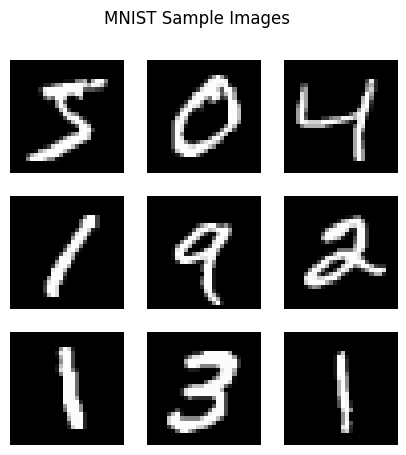

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to 0..1
x_train = x_train / 255.0
x_test  = x_test / 255.0

# Show sample images (3x3)
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.suptitle("MNIST Sample Images")
plt.show()


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

model.save("mnist_model.h5")
print("✅ Model training complete and saved as mnist_model.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8809 - loss: 0.4284 - val_accuracy: 0.9631 - val_loss: 0.1303
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9662 - loss: 0.1170 - val_accuracy: 0.9685 - val_loss: 0.1054
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9770 - loss: 0.0770 - val_accuracy: 0.9742 - val_loss: 0.0829
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9823 - loss: 0.0569 - val_accuracy: 0.9771 - val_loss: 0.0744
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9874 - loss: 0.0418 - val_accuracy: 0.9778 - val_loss: 0.0773


✅ Model training complete and saved as mnist_model.h5


### TensorFlow Lite Conversion
This section converts the trained Keras model into TensorFlow Lite format for deployment.


Part 3 — Convert to TensorFlow **Lite**

In [ ]:
# Load model
model = tf.keras.models.load_model("mnist_model.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save TFLite model
with open("mnist_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model successfully converted and saved as mnist_model.tflite")


Saved artifact at '/tmp/tmpmte2rxbi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133964113983056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133964113980176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133964074534096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133964074533328: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model successfully converted and saved as mnist_model.tflite


### TensorFlow Lite Inference
This section loads the TFLite model and performs inference using the TFLite Interpreter.


**Part 4 — Load with Interpreter + Inference**

In [ ]:
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:", input_details)
print("Output Details:", output_details)


Input Details: [{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


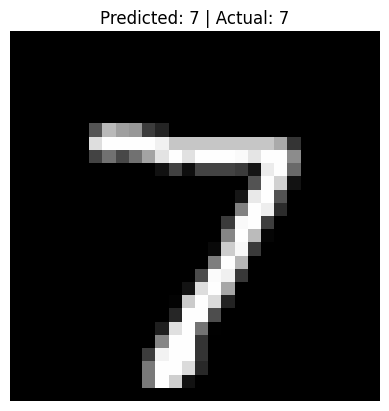

Raw probabilities: [[4.4015458e-08 2.1950958e-08 1.2004954e-05 1.7795019e-04 1.6676473e-10
  1.6665496e-07 4.0894094e-12 9.9980313e-01 4.6008745e-06 2.0323282e-06]]


In [ ]:
# Select test image
test_image = x_test[0].astype(np.float32)
test_image = np.expand_dims(test_image, axis=0)  # shape (1,28,28)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], test_image)

# Run inference
interpreter.invoke()

# Get output
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Show result
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Predicted: {predicted_label} | Actual: {y_test[0]}")
plt.axis("off")
plt.show()

print("Raw probabilities:", output_data)


In [ ]:
import random

correct = 0
n = 10

for _ in range(n):
    idx = random.randint(0, len(x_test)-1)
    img = x_test[idx].astype(np.float32)
    img_input = np.expand_dims(img, axis=0)

    interpreter.set_tensor(input_details[0]['index'], img_input)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(out)

    if pred == y_test[idx]:
        correct += 1

print(f"✅ Accuracy on {n} random samples: {correct}/{n}")


✅ Accuracy on 10 random samples: 9/10
